## Imports

In [1]:
import sys
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd().parents[0]))

import scripts.prepare as prepare
import scripts.services as services
import scripts.roi as roi_services
import scripts.bss_pipeline as bss_pl
import scripts.visualization as vis

from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [2]:
N_PC = 10 # discovered by analysis
NFRAMES_OUT = 1200
SCALE_OUT = 0.2
FPS_OUT = 240
N_PEAKS = 5
ROIS = roi_services.load_rois(str(Path.cwd().parents[0] / "rois/rois.json"))
BASE_DIR = (Path.cwd().parents[0] / "videos" / "camp_3")

### load video paths

In [11]:
p1_video_paths = services.get_video_paths(base_dir=BASE_DIR, start_date="25/05/2026", end_date="31/05/2026", plant_id=1, periods=("m, n"))
p2_video_paths = services.get_video_paths(base_dir=BASE_DIR, start_date="25/05/2026", end_date="31/05/2026", plant_id=2, periods=("m, n"))

### methodology

In [12]:
def apply_methodology(video_paths):
    results = []
    
    progress = tqdm(total=len(video_paths), desc="Processando vídeos", unit="vídeo")

    for VIDEO_PATH_IN in video_paths:
        VIDEO_NAME = VIDEO_PATH_IN.name
        
        progress.set_postfix_str(f"Processando: {VIDEO_NAME}")
            
        VIDEO_PATH_OUT = str(Path.cwd().parents[0] / "outputs/misc" / VIDEO_NAME)
        
        VIDEO_ROI = ROIS[VIDEO_NAME]
        
        prepare.pre_processing(VIDEO_PATH_IN, VIDEO_PATH_OUT, NFRAMES_OUT, FPS_OUT, SCALE_OUT, VIDEO_ROI)
        
        video_out_info = services.get_video_info(VIDEO_PATH_OUT)
        
        unmixed, winvmix, w, h = bss_pl.run_pipeline(VIDEO_PATH_OUT, N_PC)
        
        fft_data = bss_pl.compute_fft_for_components(unmixed, video_out_info["fps"], range(N_PC))
        peaks_info = bss_pl.get_highest_peak_frequencies(fft_data, N_PEAKS)
        
        amp, freq, source = services.get_dominant_source(peaks_info, frequency_threshold = 1.0)
        
        results.append({
            "date": VIDEO_PATH_IN.parent.parent.parent.name,
            "plant_id": VIDEO_PATH_IN.parent.parent.name.split("_")[-1],
            "period": VIDEO_PATH_IN.parent.name,
            "video": VIDEO_PATH_IN.name,
            "frequency": freq,
            "amplitude": amp,
            "source": source,
        })
        
        # Exibe o resultado parcial na barra
        progress.set_postfix({"freq": f"{freq:.2f} Hz", "amp": f"{amp:.2f}", "source": source})
        
        tqdm.write(f"{VIDEO_NAME} | plant={results[-1]['plant_id']} | period={results[-1]['period']} | freq={freq:.2f} Hz | amp={amp:.2f} | source={source}")
        
        # Avança explicitamente 1 vídeo
        progress.update(1)
    
    progress.close()  
    
    return results

In [13]:
p1_results = apply_methodology(p1_video_paths)
p2_results = apply_methodology(p2_video_paths)

Processando vídeos:   0%|          | 0/14 [00:00<?, ?vídeo/s]

VID_20260525_073740210.mp4 | plant=1 | period=m | freq=2.20 Hz | amp=197.77 | source=8
VID_20260525_185103702.mp4 | plant=1 | period=n | freq=2.40 Hz | amp=159.73 | source=8
VID_20260526_073704629.mp4 | plant=1 | period=m | freq=2.40 Hz | amp=162.05 | source=5
VID_20260526_202725561.mp4 | plant=1 | period=n | freq=1.20 Hz | amp=121.25 | source=9
VID_20260527_073900146.mp4 | plant=1 | period=m | freq=2.00 Hz | amp=92.39 | source=8
VID_20260527_202243346.mp4 | plant=1 | period=n | freq=1.80 Hz | amp=213.03 | source=9
VID_20260528_060712313.mp4 | plant=1 | period=m | freq=2.00 Hz | amp=143.15 | source=9
VID_20260528_194053898.mp4 | plant=1 | period=n | freq=2.80 Hz | amp=146.99 | source=7
VID_20260529_083217557.mp4 | plant=1 | period=m | freq=1.20 Hz | amp=138.25 | source=8
VID_20260529_200346418.mp4 | plant=1 | period=n | freq=1.80 Hz | amp=103.50 | source=9
VID_20260530_074908974.mp4 | plant=1 | period=m | freq=2.20 Hz | amp=219.22 | source=8
VID_20260530_212358245.mp4 | plant=1 | perio

Processando vídeos:   0%|          | 0/14 [00:00<?, ?vídeo/s]

VID_20260525_073831392.mp4 | plant=2 | period=m | freq=2.00 Hz | amp=129.90 | source=9
VID_20260525_185326185.mp4 | plant=2 | period=n | freq=1.20 Hz | amp=194.79 | source=9
VID_20260526_073755265.mp4 | plant=2 | period=m | freq=1.60 Hz | amp=231.64 | source=9
VID_20260526_202842902.mp4 | plant=2 | period=n | freq=2.00 Hz | amp=160.66 | source=9
VID_20260527_074035158.mp4 | plant=2 | period=m | freq=1.40 Hz | amp=127.45 | source=8
VID_20260527_202347776.mp4 | plant=2 | period=n | freq=2.00 Hz | amp=153.20 | source=8
VID_20260528_060627096.mp4 | plant=2 | period=m | freq=2.00 Hz | amp=181.20 | source=9
VID_20260528_194140546.mp4 | plant=2 | period=n | freq=1.20 Hz | amp=372.68 | source=9
VID_20260529_083140178.mp4 | plant=2 | period=m | freq=1.60 Hz | amp=123.32 | source=9
VID_20260529_200501170.mp4 | plant=2 | period=n | freq=1.20 Hz | amp=169.49 | source=3
VID_20260530_074702260.mp4 | plant=2 | period=m | freq=1.60 Hz | amp=118.94 | source=9
VID_20260530_212439482.mp4 | plant=2 | peri

### plots

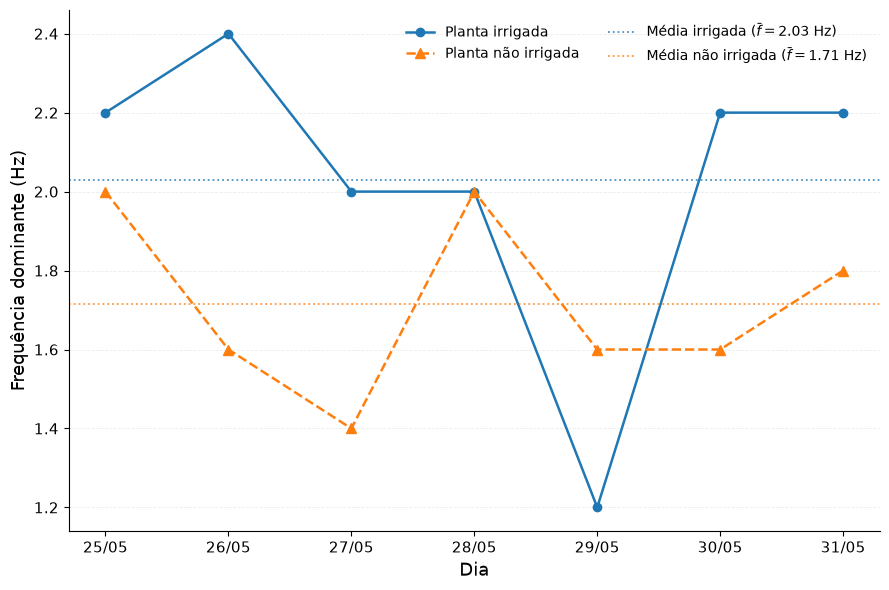

In [10]:
dias = [datetime.strptime(r["date"], "%Y%m%d").strftime("%d/%m") for r in p1_results]

planta_irrigada = [round(r["frequency"], 2) for r in p1_results]
planta_nao_irrigada = [round(r["frequency"], 2) for r in p2_results]

media_irrigada = np.mean(planta_irrigada)
media_nao_irrigada = np.mean(planta_nao_irrigada)

fig, ax = plt.subplots(figsize=(9, 6))

# Séries temporais
line1, = ax.plot(dias, planta_irrigada, marker="o", markersize=6, linewidth=1.8, label="Planta irrigada")
line2, = ax.plot(dias, planta_nao_irrigada, marker="^", markersize=7, linestyle="--", linewidth=1.8, label="Planta não irrigada")

# Médias
ax.axhline(media_irrigada, linestyle=":", linewidth=1.3, alpha=0.8, color=line1.get_color(), label=rf"Média irrigada ($\bar{{f}}={media_irrigada:.2f}$ Hz)")
ax.axhline(media_nao_irrigada, linestyle=":", linewidth=1.3, alpha=0.8, color=line2.get_color(), label=rf"Média não irrigada ($\bar{{f}}={media_nao_irrigada:.2f}$ Hz)")

# Eixos
ax.set_xlabel("Dia", fontsize=13)
ax.set_ylabel("Frequência dominante (Hz)", fontsize=13)

ax.tick_params(axis="both", labelsize=11)

# Grade discreta apenas no eixo y
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)

# Remove bordas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legenda
ax.legend(fontsize=10, frameon=False, ncol=2)

fig.tight_layout()

# fig.savefig("frequencias_plantas_2.pdf", format="pdf", bbox_inches="tight")

plt.show()

#### day and night

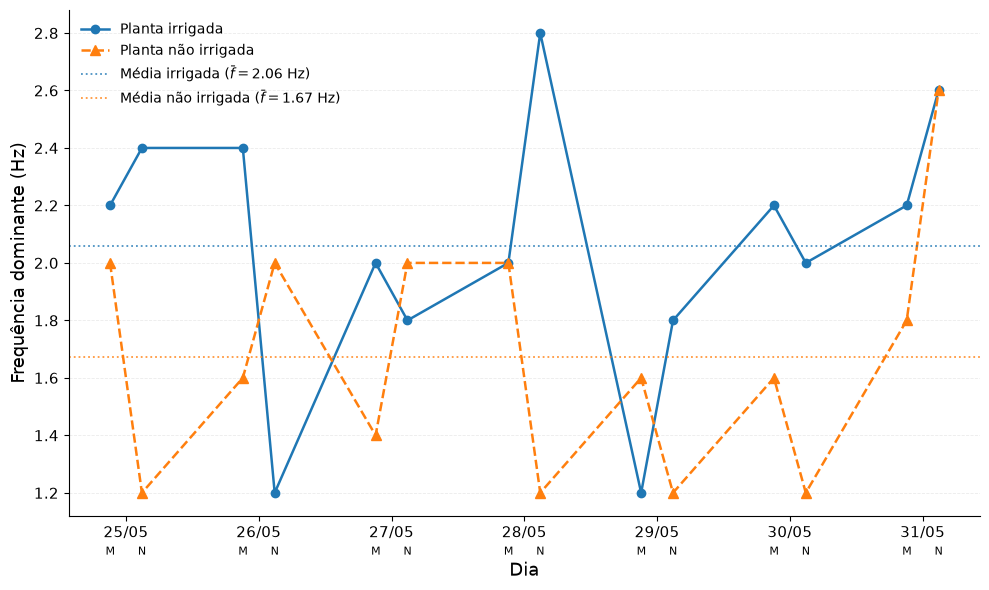

In [19]:
dates = list(dict.fromkeys(r["date"] for r in p1_results))

dias = [datetime.strptime(date, "%Y%m%d").strftime("%d/%m") for date in dates]

# Posição central de cada dia
x = np.arange(len(dates))

# Deslocamento da manhã e noite em relação ao centro do dia
shift = 0.12

x_morning = x - shift
x_night = x + shift

# ============================================================
# Função auxiliar
# ============================================================

def get_frequency(results, date, period):
    for r in results:
        if r["date"] == date and r["period"] == period:
            return round(r["frequency"], 2)

    return np.nan

# ============================================================
# Frequências da planta irrigada
# ============================================================
p1_morning = np.array([get_frequency(p1_results, date, "m") for date in dates])
p1_night = np.array([get_frequency(p1_results, date, "n") for date in dates])

# ============================================================
# Frequências da planta não irrigada
# ============================================================
p2_morning = np.array([get_frequency(p2_results, date, "m") for date in dates])
p2_night = np.array([get_frequency(p2_results, date, "n") for date in dates])


# ============================================================
# Intercala manhã e noite
#
# Resultado:
# dia1-m, dia1-n, dia2-m, dia2-n, ...
# ============================================================
x_series = np.column_stack((x_morning, x_night)).ravel()
planta_irrigada = np.column_stack((p1_morning, p1_night)).ravel()
planta_nao_irrigada = np.column_stack((p2_morning, p2_night)).ravel()

# ============================================================
# Médias
# ============================================================
media_irrigada = np.nanmean(planta_irrigada)
media_nao_irrigada = np.nanmean(planta_nao_irrigada)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
# Planta irrigada
line1, = ax.plot(x_series, planta_irrigada, marker="o", markersize=6, linewidth=1.8, label="Planta irrigada")
# Planta não irrigada
line2, = ax.plot(x_series, planta_nao_irrigada, marker="^", markersize=7, linestyle="--", linewidth=1.8, label="Planta não irrigada")

# ============================================================
# Médias
# ============================================================
ax.axhline(media_irrigada, linestyle=":", linewidth=1.3, alpha=0.8, color=line1.get_color(), label=rf"Média irrigada ($\bar{{f}}={media_irrigada:.2f}$ Hz)")
ax.axhline(media_nao_irrigada, linestyle=":", linewidth=1.3, alpha=0.8, color=line2.get_color(), label=rf"Média não irrigada ($\bar{{f}}={media_nao_irrigada:.2f}$ Hz)")


# ============================================================
# Eixo X
# ============================================================
# Tick no centro entre manhã e noite
ax.set_xticks(x)
ax.set_xticklabels(dias)
ax.set_xlabel("Dia", fontsize=13, labelpad=15)
ax.set_ylabel("Frequência dominante (Hz)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

# ============================================================
# Identificação de manhã/noite
# ============================================================
# Pequenas marcações abaixo do eixo indicando m/n
for xm, xn in zip(x_morning, x_night):
    ax.text(xm, -0.06, "M", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=8)
    ax.text(xn, -0.06, "N", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=8)

# ============================================================
# Grade
# ============================================================
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)

# Remove bordas superior e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ============================================================
# Legenda
# ============================================================
ax.legend(fontsize=10, frameon=False, ncol=1)

# Espaço adicional para M/N abaixo das datas
fig.subplots_adjust(bottom=0.16)
fig.tight_layout()

# ============================================================
# Salva
# ============================================================
# fig.savefig("frequencias_plantas_manha_noite.pdf", format="pdf", bbox_inches="tight")

plt.show()